In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

DATA_DIR = Path("london_final_dataset")

TARGET = "pm25"

DROP_COLS = ["date", TARGET]

MODEL_DIR = Path("saved_con_xgb")
MODEL_DIR.mkdir(exist_ok=True)

RESULTS_DIR = Path("xgb_results")
RESULTS_DIR.mkdir(exist_ok=True)

FORECAST_HORIZONS = [1, 7, 14, 30]

RANDOM_STATE = 42

In [5]:
# ============================================================
# 3. DATASET PATHS
# ============================================================

TRAIN_PATH = DATA_DIR / "marylebone_train.csv"
TEST_PATH = DATA_DIR / "marylebone_test.csv"
ALL_PATH = DATA_DIR / "marylebone_all.csv"

print("Train:", TRAIN_PATH)
print("Test :", TEST_PATH)
print("All  :", ALL_PATH)

print("\nFiles found:")
print("Train:", TRAIN_PATH.exists())
print("Test :", TEST_PATH.exists())
print("All  :", ALL_PATH.exists())

Train: london_final_dataset/marylebone_train.csv
Test : london_final_dataset/marylebone_test.csv
All  : london_final_dataset/marylebone_all.csv

Files found:
Train: True
Test : True
All  : True


In [7]:
# ============================================================
# 4. LOAD AND PREPARE DATA
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
df = pd.read_csv(ALL_PATH)

for dataset in [train_df, test_df, df]:
    dataset["date"] = pd.to_datetime(dataset["date"])
    dataset.sort_values("date", inplace=True)
    dataset.reset_index(drop=True, inplace=True)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Full shape :", df.shape)

print("\nTraining period:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTesting period:")
print(test_df["date"].min(), "to", test_df["date"].max())

Train shape: (1000, 42)
Test shape : (364, 42)
Full shape : (1364, 42)

Training period:
2022-04-07 00:00:00 to 2024-12-31 00:00:00

Testing period:
2025-01-01 00:00:00 to 2025-12-30 00:00:00


In [9]:
# ============================================================
# 5. TRAIN / TEST BOUNDARIES
# ============================================================

TRAIN_END = train_df["date"].max()
TEST_START = test_df["date"].min()
TEST_END = test_df["date"].max()

print("Train end :", TRAIN_END)
print("Test start:", TEST_START)
print("Test end  :", TEST_END)

Train end : 2024-12-31 00:00:00
Test start: 2025-01-01 00:00:00
Test end  : 2025-12-30 00:00:00


In [11]:
# ============================================================
# 6. FEATURES
# ============================================================

features = [
    col
    for col in df.columns
    if col not in DROP_COLS
]

print("Number of features:", len(features))

for feature in features:
    print(feature)

Number of features: 40
year
month
day_of_month
day_of_week_x
day_of_year
week_of_year
quarter
is_weekend
is_weekday
season_code
month_sin
month_cos
doy_sin
doy_cos
dow_sin
dow_cos
week_sin
week_cos
pm25_lag1
pm25_lag7
pm25_rollmean3
pm25_rollstd3
day_of_week_y
quarter_num
mean_relative_humidity_pct
relative_humidity_max_pct
relative_humidity_min_pct
total_precipitation_mm
precipitation_max_mm
precipitation_min_mm
mean_air_pressure_hpa
air_pressure_max_hpa
air_pressure_min_hpa
temperature_max_c
temperature_min_c
temperature_avg_c
mean_wind_speed_knots
wind_speed_max_knots
wind_speed_min_knots
wind_direction_deg


In [13]:
# ============================================================
# 7. XGBOOST HYPERPARAMETER SEARCH SPACE
# ============================================================

PARAM_GRID = {
    "n_estimators": [200, 300, 500, 700],

    "max_depth": [2, 3, 4, 5, 6],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.6,
        0.8,
        1.0
    ],

    "min_child_weight": [
        1,
        3,
        5,
        7
    ],

    "gamma": [
        0,
        0.05,
        0.1,
        0.2
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1,
        1.0
    ],

    "reg_lambda": [
        0.5,
        1.0,
        2.0,
        5.0
    ]
}

print("XGBoost parameter grid ready.")

XGBoost parameter grid ready.


In [15]:
# ============================================================
# XGBOOST MULTI-HORIZON MODELLING
# ============================================================

results = []
best_models = {}
predictions = {}
feature_importances = {}

for horizon in FORECAST_HORIZONS:

    print("\n" + "=" * 75)
    print(f"XGBOOST — {horizon}-DAY-AHEAD PM2.5 FORECAST")
    print("=" * 75)

    # --------------------------------------------------------
    # DATA FOR THIS HORIZON
    # --------------------------------------------------------

    data = df.copy()

    target_col = f"target_pm25_{horizon}d"
    target_date_col = f"target_date_{horizon}d"

    data[target_col] = data[TARGET].shift(-horizon)
    data[target_date_col] = data["date"].shift(-horizon)

    data = data.dropna(
        subset=[target_col, target_date_col]
    ).copy()

    # --------------------------------------------------------
    # TRAINING DATA
    # --------------------------------------------------------

    train_data = data[
        (data["date"] <= TRAIN_END)
        &
        (data[target_date_col] <= TRAIN_END)
    ].copy()

    # --------------------------------------------------------
    # TEST DATA
    # --------------------------------------------------------

    test_data = data[
        (data["date"] >= TEST_START)
        &
        (data["date"] <= TEST_END)
        &
        (data[target_date_col] <= TEST_END)
    ].copy()

    X_train = train_data[features].copy()
    y_train = train_data[target_col].copy()

    X_test = test_data[features].copy()
    y_test = test_data[target_col].copy()

    print(
        f"Training observations: {len(X_train)}"
    )

    print(
        f"Testing observations : {len(X_test)}"
    )

    # --------------------------------------------------------
    # TIME SERIES CV
    # --------------------------------------------------------

    tscv = TimeSeriesSplit(
        n_splits=5,
        gap=horizon
    )

    # --------------------------------------------------------
    # XGBOOST
    # --------------------------------------------------------

    base_xgb = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1
    )

    # --------------------------------------------------------
    # HYPERPARAMETER OPTIMISATION
    # --------------------------------------------------------

    search = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=PARAM_GRID,
        n_iter=30,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search.fit(
        X_train,
        y_train
    )

    best_xgb = search.best_estimator_

    best_models[horizon] = best_xgb

    cv_mae = -search.best_score_

    print("\nBest Parameters:")
    print(search.best_params_)

    print(
        f"Cross-validation MAE: {cv_mae:.4f}"
    )

    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    y_pred = best_xgb.predict(
        X_test
    )

    # --------------------------------------------------------
    # XGBOOST METRICS
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    # --------------------------------------------------------
    # PERSISTENCE BASELINE
    # --------------------------------------------------------

    persistence_pred = (
        test_data[TARGET]
        .to_numpy()
    )

    persistence_mae = mean_absolute_error(
        y_test,
        persistence_pred
    )

    persistence_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            persistence_pred
        )
    )

    persistence_r2 = r2_score(
        y_test,
        persistence_pred
    )

    # --------------------------------------------------------
    # IMPROVEMENT OVER BASELINE
    # --------------------------------------------------------

    mae_improvement = (
        (persistence_mae - mae)
        / persistence_mae
    ) * 100

    rmse_improvement = (
        (persistence_rmse - rmse)
        / persistence_rmse
    ) * 100

    print("\nXGBoost")
    print(
        f"MAE  = {mae:.4f}"
    )
    print(
        f"RMSE = {rmse:.4f}"
    )
    print(
        f"R²   = {r2:.4f}"
    )

    print("\nPersistence")
    print(
        f"MAE  = {persistence_mae:.4f}"
    )
    print(
        f"RMSE = {persistence_rmse:.4f}"
    )
    print(
        f"R²   = {persistence_r2:.4f}"
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    results.append({
        "Horizon_Days": horizon,
        "Model": "XGBoost",
        "CV_MAE": cv_mae,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Persistence_MAE": persistence_mae,
        "Persistence_RMSE": persistence_rmse,
        "Persistence_R2": persistence_r2,
        "MAE_Improvement_Percent":
            mae_improvement,
        "RMSE_Improvement_Percent":
            rmse_improvement
    })

    # --------------------------------------------------------
    # SAVE PREDICTIONS
    # --------------------------------------------------------

    pred_df = pd.DataFrame({
        "Forecast_Origin":
            test_data["date"].to_numpy(),

        "Target_Date":
            test_data[target_date_col].to_numpy(),

        "Actual_PM25":
            y_test.to_numpy(),

        "Predicted_PM25":
            y_pred,

        "Persistence_PM25":
            persistence_pred,

        "Residual":
            y_test.to_numpy() - y_pred
    })

    predictions[horizon] = pred_df

    pred_df.to_csv(
        RESULTS_DIR
        / f"xgb_predictions_{horizon}d.csv",
        index=False
    )

    # --------------------------------------------------------
    # PERMUTATION IMPORTANCE
    # --------------------------------------------------------

    perm = permutation_importance(
        best_xgb,
        X_test,
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "Feature": features,

        "Importance_Mean":
            perm.importances_mean,

        "Importance_STD":
            perm.importances_std
    })

    importance_df = (
        importance_df
        .sort_values(
            "Importance_Mean",
            ascending=False
        )
        .reset_index(drop=True)
    )

    feature_importances[horizon] = (
        importance_df
    )

    # --------------------------------------------------------
    # SAVE MODEL
    # --------------------------------------------------------

    best_xgb.save_model(
        MODEL_DIR /
        f"xgboost_{horizon}d.json"
    )

    joblib.dump(
        best_xgb,
        MODEL_DIR /
        f"xgboost_{horizon}d.joblib"
    )

    print(
        f"\n✓ {horizon}-day model completed."
    )


XGBOOST — 1-DAY-AHEAD PM2.5 FORECAST
Training observations: 999
Testing observations : 363
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
Cross-validation MAE: 2.8048

XGBoost
MAE  = 3.1553
RMSE = 5.1732
R²   = 0.4797

Persistence
MAE  = 3.1241
RMSE = 5.6737
R²   = 0.3742

✓ 1-day model completed.

XGBOOST — 7-DAY-AHEAD PM2.5 FORECAST
Training observations: 993
Testing observations : 357
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.05, 'colsample_bytree': 0.8}
Cross-validation MAE: 3.8256

XGBoost
MAE  = 4.2915
RMSE = 6.7156
R²   = 0.1322

Persistence
MAE  = 5.7599
RMSE = 9.0458
R²   = -0.5746

✓ 7

In [17]:
# ============================================================
# FINAL RESULTS
# ============================================================

results_df = pd.DataFrame(results)

results_df = (
    results_df
    .sort_values("Horizon_Days")
    .reset_index(drop=True)
)

display(
    results_df.round(4)
)

,Horizon_Days,Model,CV_MAE,MAE,RMSE,R2,Persistence_MAE,Persistence_RMSE,Persistence_R2,MAE_Improvement_Percent,RMSE_Improvement_Percent
0,1,XGBoost,2.8048,3.1553,5.1732,0.4797,3.1241,5.6737,0.3742,-0.9992,8.8215
1,7,XGBoost,3.8256,4.2915,6.7156,0.1322,5.7599,9.0458,-0.5746,25.4943,25.7604
2,14,XGBoost,3.7240,4.2505,6.6886,0.0706,5.5098,8.5646,-0.5238,22.8557,21.9034
3,30,XGBoost,3.7697,4.3496,6.9724,-0.0717,5.1223,8.1024,-0.4472,15.0836,13.9462


In [19]:
print(
    results_df[
        [
            "Horizon_Days",
            "MAE",
            "RMSE",
            "R2"
        ]
    ]
)

print(
    "\nPrediction horizons:",
    list(predictions.keys())
)

print(
    "Importance horizons:",
    list(feature_importances.keys())
)

   Horizon_Days       MAE      RMSE        R2
0             1  3.155274  5.173167  0.479709
1             7  4.291485  6.715592  0.132174
2            14  4.250505  6.688632  0.070637
3            30  4.349635  6.972420 -0.071714

Prediction horizons: [1, 7, 14, 30]
Importance horizons: [1, 7, 14, 30]


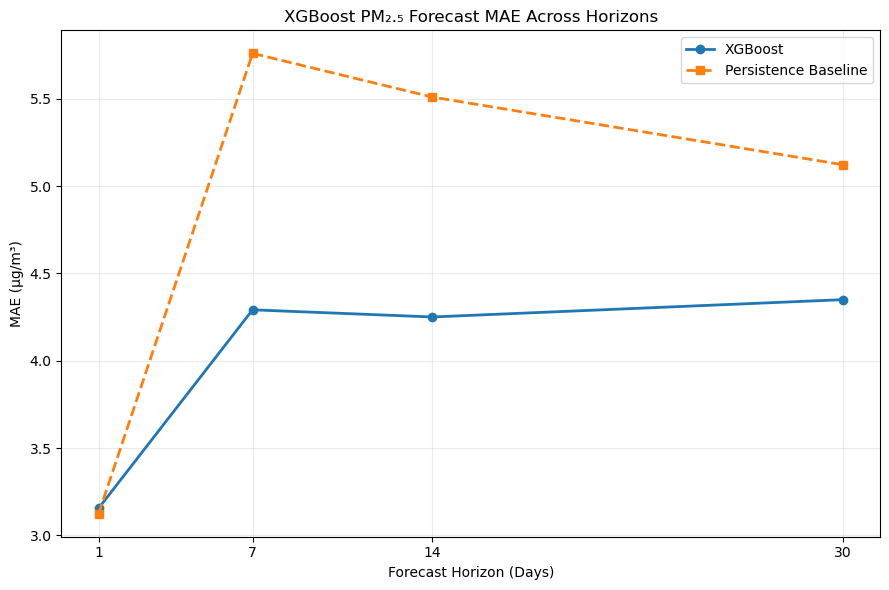

In [21]:
# ============================================================
# PLOT 1 — MAE: XGBOOST VS PERSISTENCE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    results_df["Horizon_Days"],
    results_df["MAE"],
    marker="o",
    linewidth=2,
    label="XGBoost"
)

plt.plot(
    results_df["Horizon_Days"],
    results_df["Persistence_MAE"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Persistence Baseline"
)

plt.xlabel("Forecast Horizon (Days)")
plt.ylabel("MAE (µg/m³)")
plt.title("XGBoost PM₂.₅ Forecast MAE Across Horizons")

plt.xticks([1, 7, 14, 30])
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

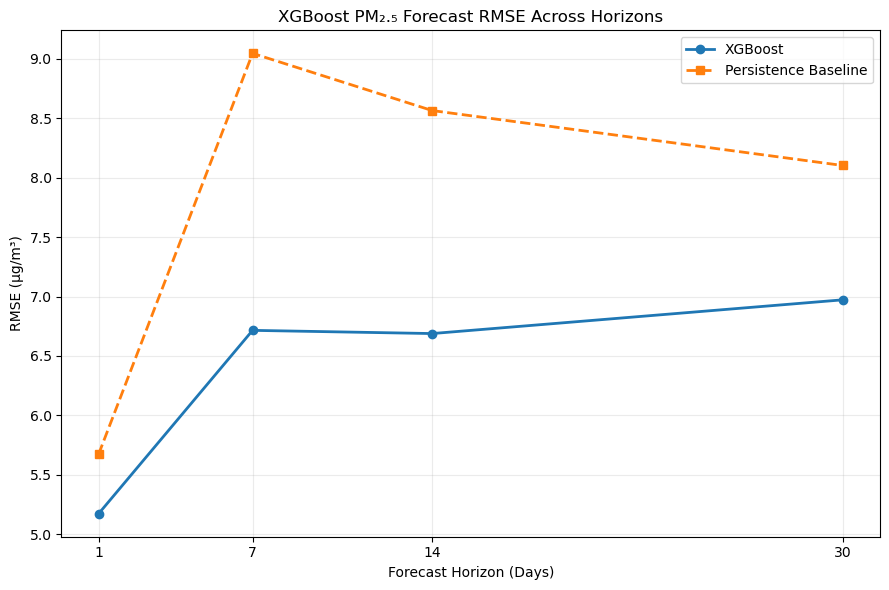

In [23]:
# ============================================================
# PLOT 2 — RMSE: XGBOOST VS PERSISTENCE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    results_df["Horizon_Days"],
    results_df["RMSE"],
    marker="o",
    linewidth=2,
    label="XGBoost"
)

plt.plot(
    results_df["Horizon_Days"],
    results_df["Persistence_RMSE"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Persistence Baseline"
)

plt.xlabel("Forecast Horizon (Days)")
plt.ylabel("RMSE (µg/m³)")
plt.title("XGBoost PM₂.₅ Forecast RMSE Across Horizons")

plt.xticks([1, 7, 14, 30])
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

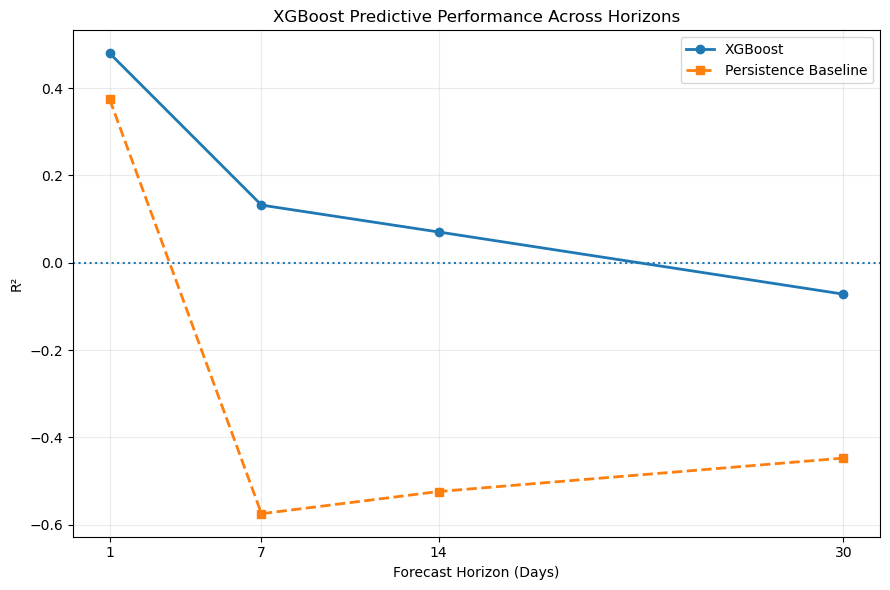

In [25]:
# ============================================================
# PLOT 3 — R² ACROSS HORIZONS
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    results_df["Horizon_Days"],
    results_df["R2"],
    marker="o",
    linewidth=2,
    label="XGBoost"
)

plt.plot(
    results_df["Horizon_Days"],
    results_df["Persistence_R2"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Persistence Baseline"
)

plt.axhline(
    y=0,
    linestyle=":",
    linewidth=1.5
)

plt.xlabel("Forecast Horizon (Days)")
plt.ylabel("R²")
plt.title("XGBoost Predictive Performance Across Horizons")

plt.xticks([1, 7, 14, 30])
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

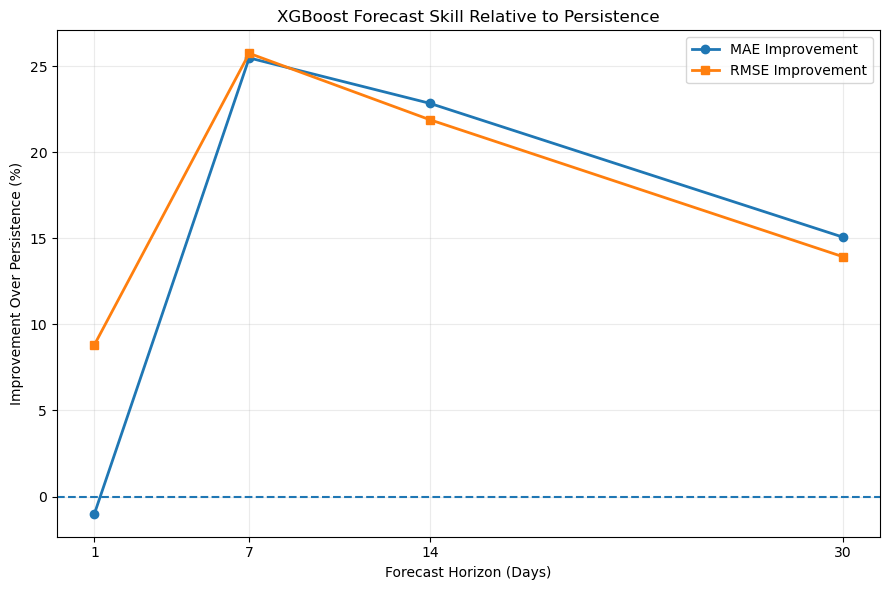

In [27]:
# ============================================================
# PLOT 4 — FORECAST SKILL OVER PERSISTENCE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    results_df["Horizon_Days"],
    results_df["MAE_Improvement_Percent"],
    marker="o",
    linewidth=2,
    label="MAE Improvement"
)

plt.plot(
    results_df["Horizon_Days"],
    results_df["RMSE_Improvement_Percent"],
    marker="s",
    linewidth=2,
    label="RMSE Improvement"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Forecast Horizon (Days)")
plt.ylabel("Improvement Over Persistence (%)")

plt.title(
    "XGBoost Forecast Skill Relative to Persistence"
)

plt.xticks([1, 7, 14, 30])

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

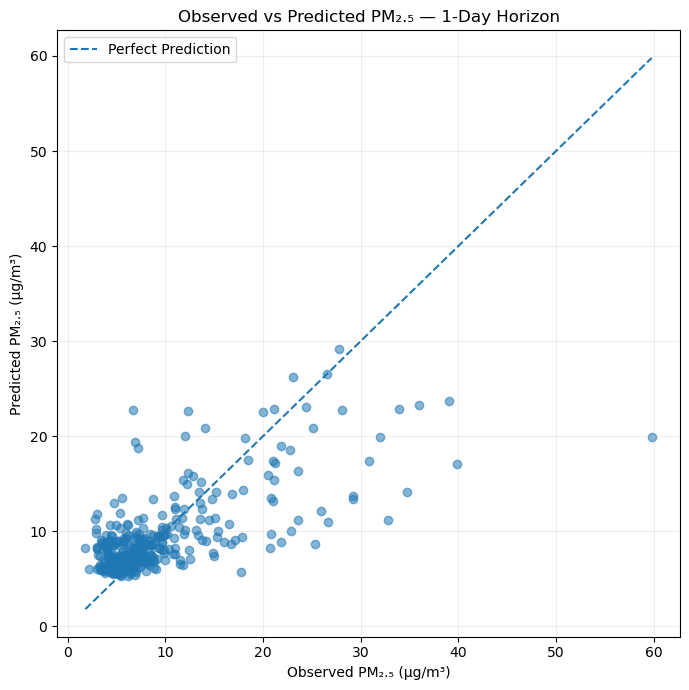

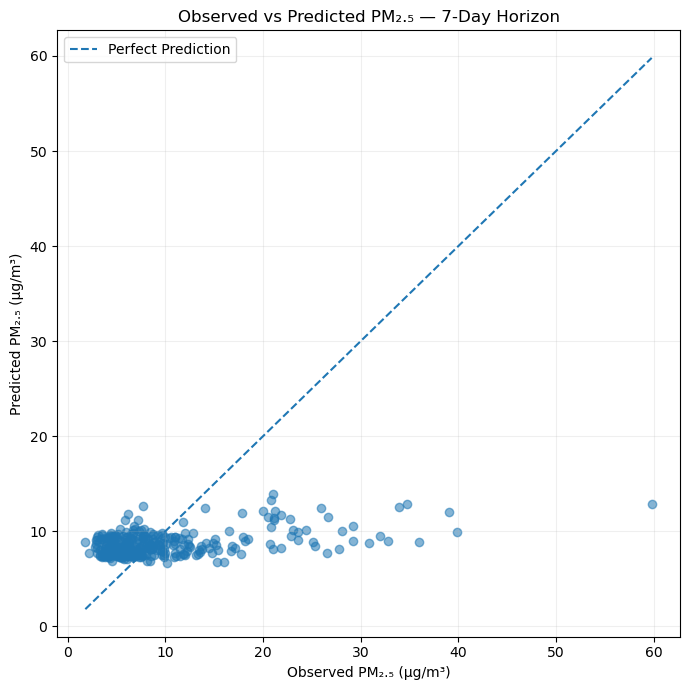

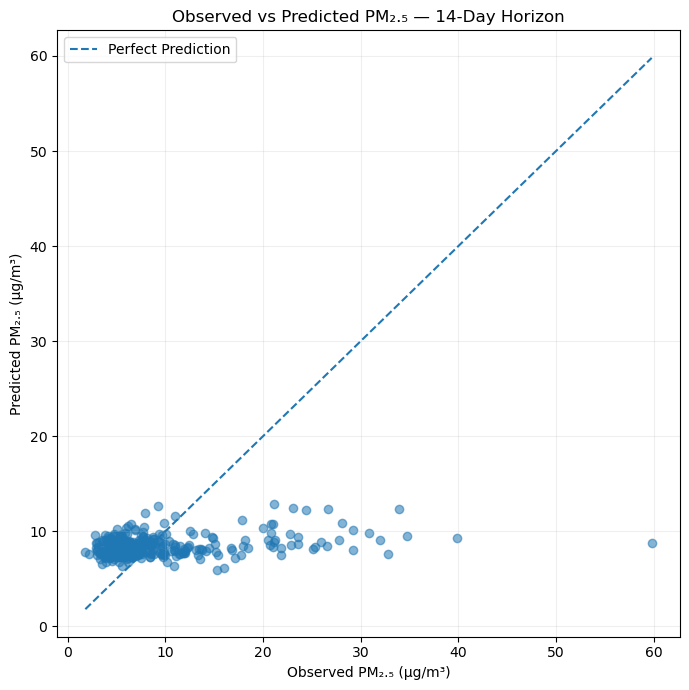

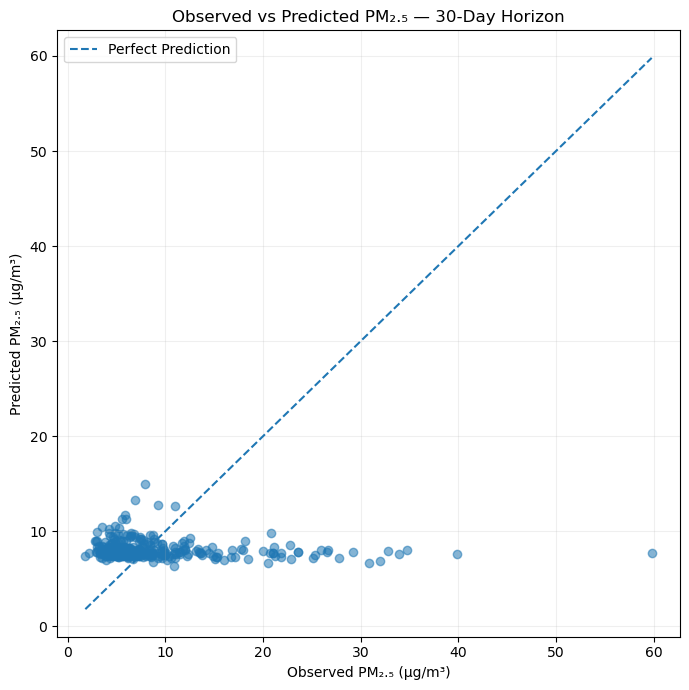

In [29]:
# ============================================================
# PLOT 6 — OBSERVED VS PREDICTED SCATTER
# ============================================================

for horizon in FORECAST_HORIZONS:

    pred_df = predictions[horizon]

    actual = pred_df["Actual_PM25"].to_numpy()
    predicted = pred_df["Predicted_PM25"].to_numpy()

    lower = min(actual.min(), predicted.min())
    upper = max(actual.max(), predicted.max())

    plt.figure(figsize=(7, 7))

    plt.scatter(
        actual,
        predicted,
        alpha=0.55
    )

    plt.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1.5,
        label="Perfect Prediction"
    )

    plt.xlabel("Observed PM₂.₅ (µg/m³)")
    plt.ylabel("Predicted PM₂.₅ (µg/m³)")

    plt.title(
        f"Observed vs Predicted PM₂.₅ — "
        f"{horizon}-Day Horizon"
    )

    plt.legend()
    plt.grid(alpha=0.20)
    plt.tight_layout()

    plt.show()

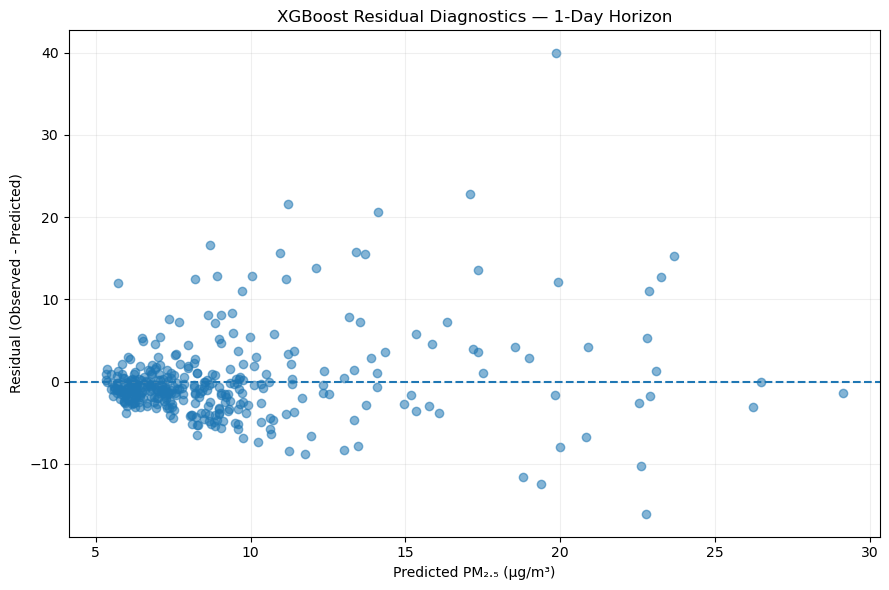

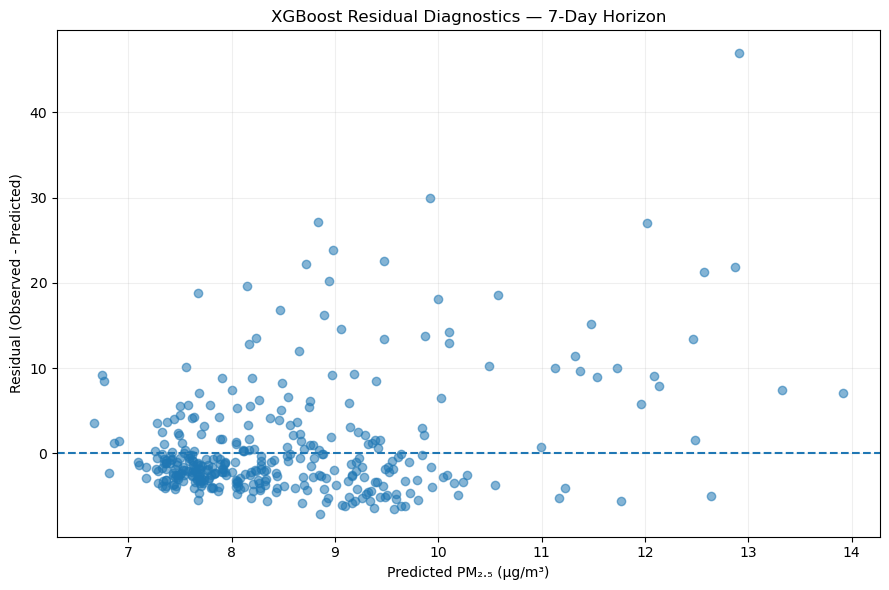

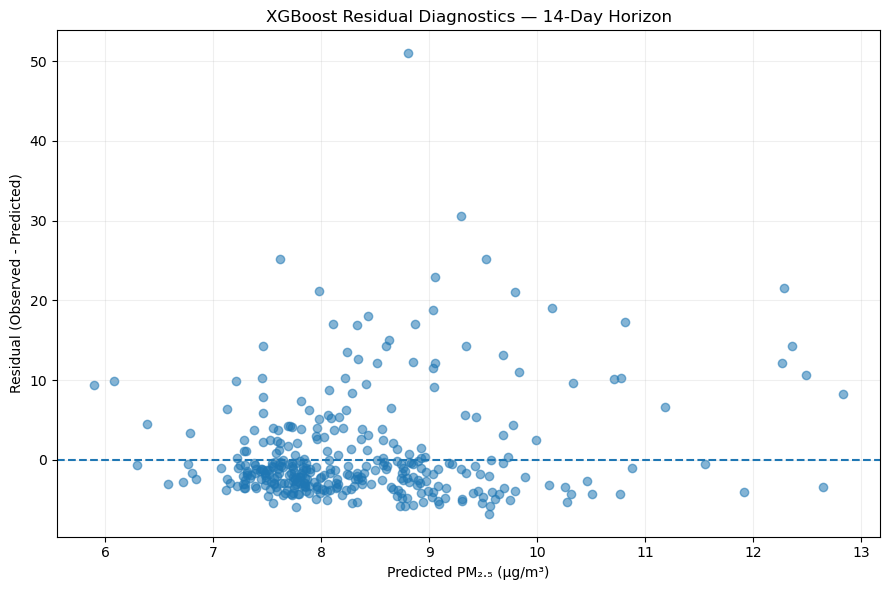

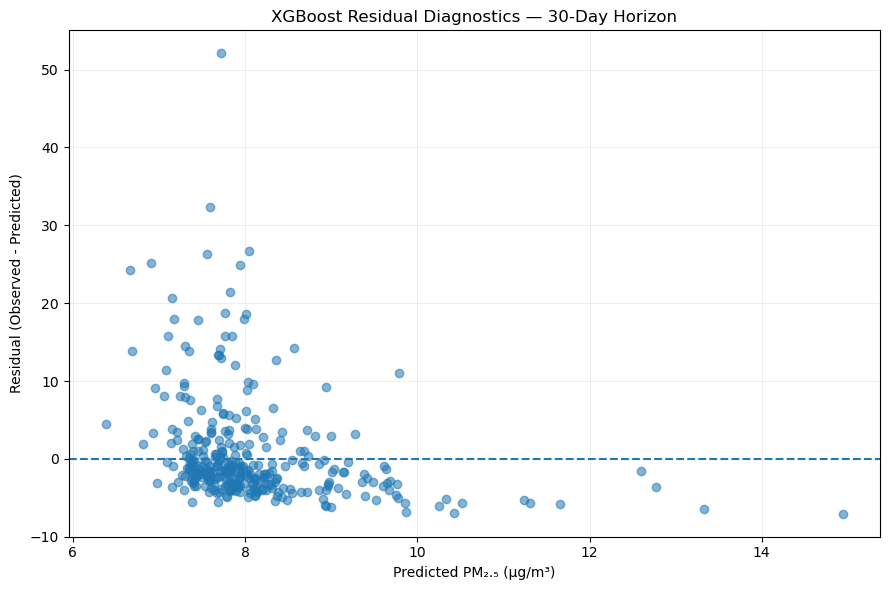

In [31]:
# ============================================================
# PLOT 7 — RESIDUAL DIAGNOSTICS
# ============================================================

for horizon in FORECAST_HORIZONS:

    pred_df = predictions[horizon]

    plt.figure(figsize=(9, 6))

    plt.scatter(
        pred_df["Predicted_PM25"],
        pred_df["Residual"],
        alpha=0.55
    )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1.5
    )

    plt.xlabel("Predicted PM₂.₅ (µg/m³)")
    plt.ylabel("Residual (Observed - Predicted)")

    plt.title(
        f"XGBoost Residual Diagnostics — "
        f"{horizon}-Day Horizon"
    )

    plt.grid(alpha=0.20)
    plt.tight_layout()

    plt.show()

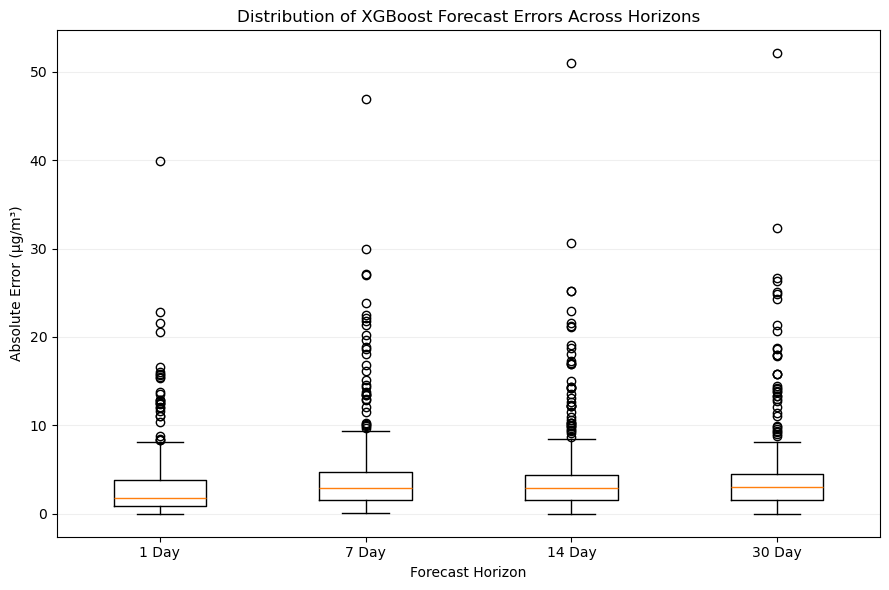

In [33]:
# ============================================================
# PLOT 8 — ABSOLUTE ERROR DISTRIBUTION
# ============================================================

error_data = []
labels = []

for horizon in FORECAST_HORIZONS:

    pred_df = predictions[horizon]

    absolute_error = np.abs(
        pred_df["Actual_PM25"]
        - pred_df["Predicted_PM25"]
    )

    error_data.append(absolute_error)

    labels.append(
        f"{horizon} Day"
    )

plt.figure(figsize=(9, 6))

plt.boxplot(
    error_data,
    tick_labels=labels,
    showfliers=True
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Absolute Error (µg/m³)")

plt.title(
    "Distribution of XGBoost Forecast Errors "
    "Across Horizons"
)

plt.grid(
    axis="y",
    alpha=0.20
)

plt.tight_layout()
plt.show()

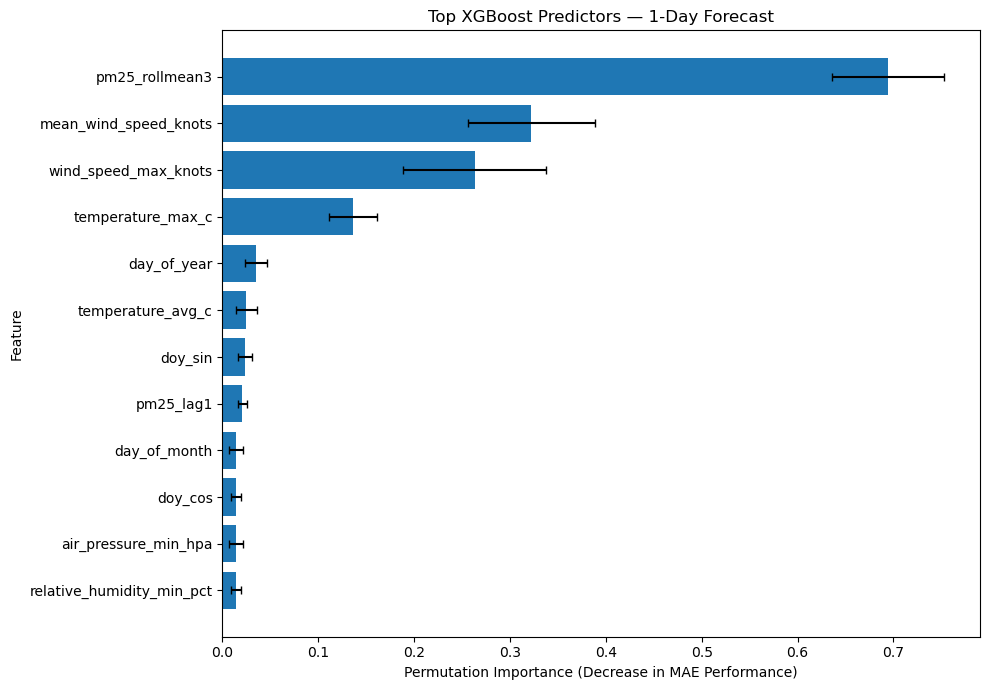

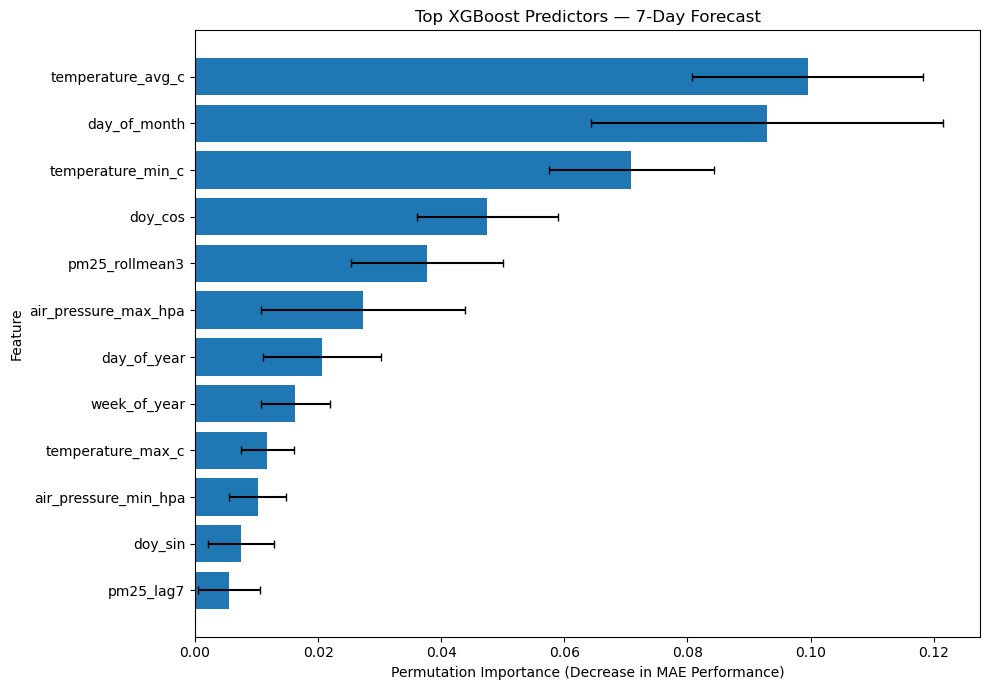

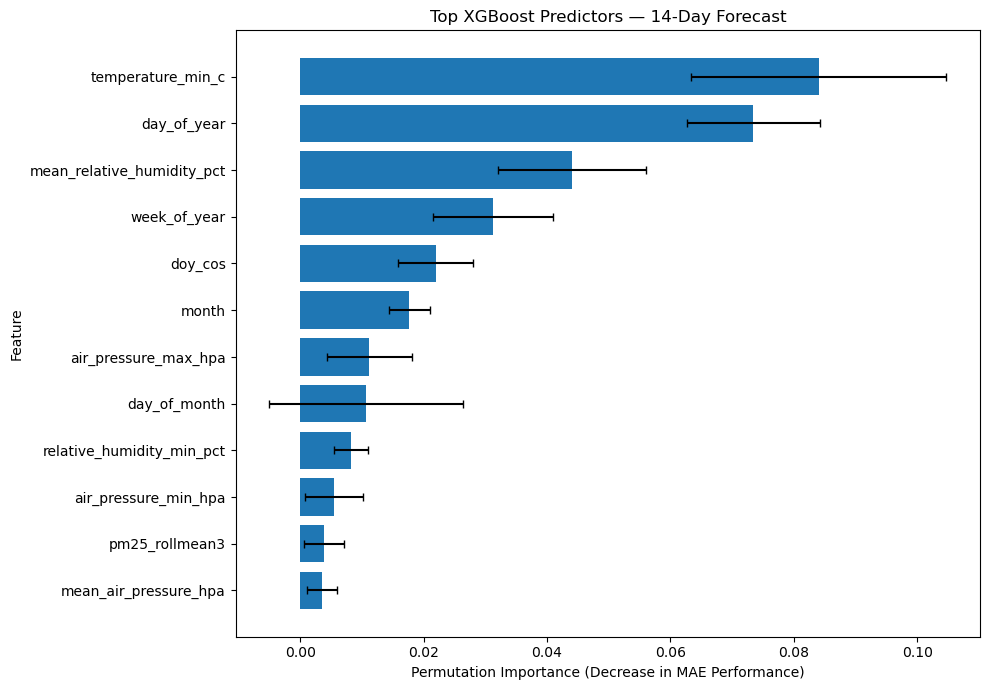

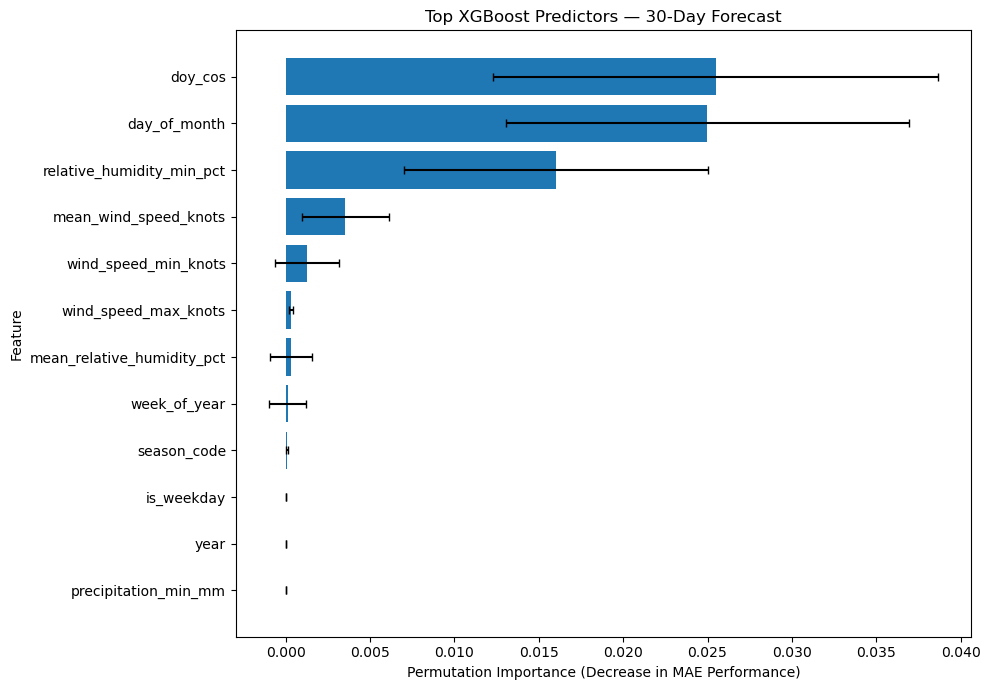

In [35]:
# ============================================================
# PLOT 9 — PERMUTATION FEATURE IMPORTANCE
# ============================================================

for horizon in FORECAST_HORIZONS:

    importance_df = (
        feature_importances[horizon]
        .head(12)
        .sort_values(
            "Importance_Mean",
            ascending=True
        )
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance_Mean"],
        xerr=importance_df["Importance_STD"],
        capsize=3
    )

    plt.xlabel(
        "Permutation Importance "
        "(Decrease in MAE Performance)"
    )

    plt.ylabel("Feature")

    plt.title(
        f"Top XGBoost Predictors — "
        f"{horizon}-Day Forecast"
    )

    plt.tight_layout()
    plt.show()

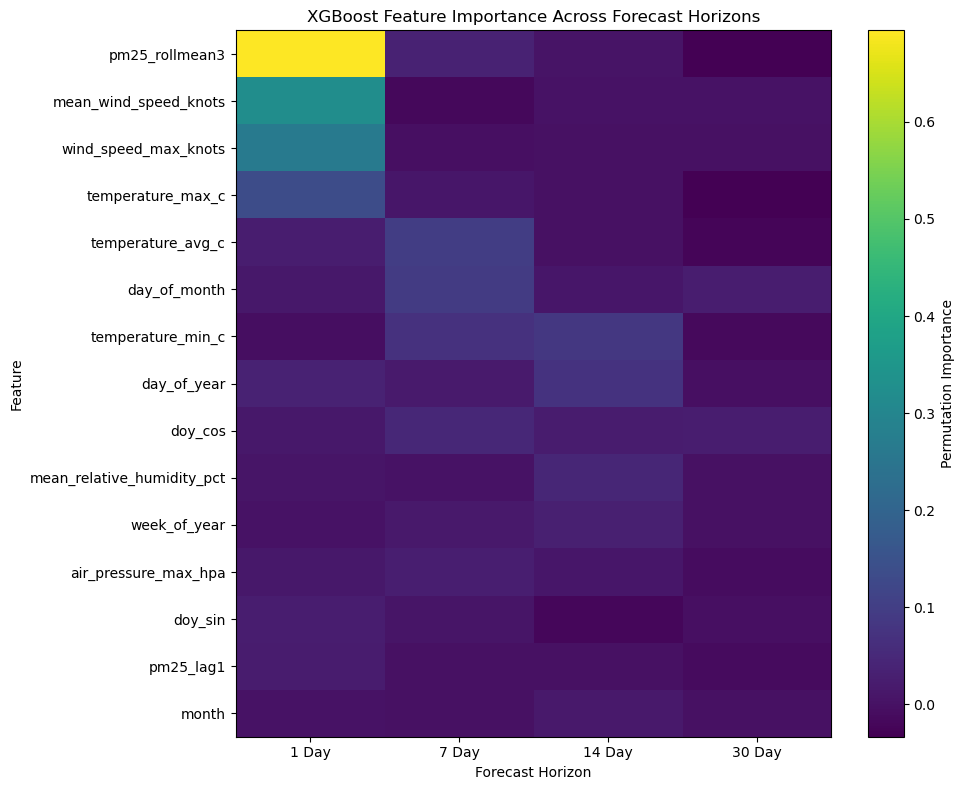

In [37]:
# ============================================================
# PLOT 10 — FEATURE IMPORTANCE ACROSS HORIZONS
# ============================================================

importance_matrix = pd.DataFrame()

for horizon in FORECAST_HORIZONS:

    temp = (
        feature_importances[horizon]
        .set_index("Feature")["Importance_Mean"]
    )

    importance_matrix[
        f"{horizon} Day"
    ] = temp


top_features = (
    importance_matrix
    .max(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

heatmap_data = importance_matrix.loc[
    top_features
]

plt.figure(figsize=(10, 8))

image = plt.imshow(
    heatmap_data.values,
    aspect="auto"
)

plt.colorbar(
    image,
    label="Permutation Importance"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Feature")

plt.title(
    "XGBoost Feature Importance "
    "Across Forecast Horizons"
)

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# SAVE FINAL XGBOOST RESULTS
# ============================================================

results_df.to_csv(
    RESULTS_DIR /
    "xgboost_multi_horizon_results.csv",
    index=False
)

importance_matrix.to_csv(
    RESULTS_DIR /
    "xgboost_feature_importance_across_horizons.csv"
)

print("Final XGBoost results saved successfully.")

Final XGBoost results saved successfully.
